# 1.1 audio_text_sim confidence 평가

## 실험 질문

`audio_text_sim = cosine(audio_emb, text_emb)`가 confidence와 얼마나 매핑되는가?

이번 노트북은 모델 학습을 하지 않는다. cosine similarity만 사용해서 다음을 확인한다.

## 핵심 평가 방식

### A. confidence별 similarity 분포 확인

1. Confidence별 Mean ± Std Plot
2. Confidence별 Boxplot

가설이 맞다면 confidence가 1 -> 5로 올라갈수록 `audio_text_sim` 분포도 위로 이동해야 한다.

### B. cosine similarity 5구간 분류 평가

`audio_text_sim`을 낮은 순서부터 5개 구간으로 나누고, 각 구간을 예측 confidence로 본다.

```text
가장 낮은 similarity 구간 -> predicted_confidence = 1
두 번째 구간              -> predicted_confidence = 2
세 번째 구간              -> predicted_confidence = 3
네 번째 구간              -> predicted_confidence = 4
가장 높은 similarity 구간 -> predicted_confidence = 5
```

그 다음 실제 confidence와 비교해서 다음을 본다.

- 각 predicted confidence 구간에 실제 confidence 1/2/3/4/5가 몇 개 들어갔는지
- Accuracy
- Precision
- Recall
- F1
- scikit-learn classification report

주의: 이건 학습 모델이 아니라 similarity를 단순 5등분한 rule-based classifier다.

모든 output은 `deft논문기반_실험/audio_text_sim_confidence_outputs/` 안에 저장한다.

In [15]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')

HERE = Path.cwd()
if (HERE / '실험계획.md').exists():
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
META_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'

OUT_DIR = EXP_DIR / 'audio_text_sim_confidence_outputs'
PLOT_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 빠른 smoke test가 필요하면 숫자를 넣는다. 전체 실험은 None.
SAMPLE_N = None
SEED = 42

LABELS = [1, 2, 3, 4, 5]

print('ROOT:', ROOT)
print('AUDIO_EMB_DIR:', AUDIO_EMB_DIR, AUDIO_EMB_DIR.exists())
print('TEXT_EMB_DIR :', TEXT_EMB_DIR, TEXT_EMB_DIR.exists())
print('META_CSV     :', META_CSV, META_CSV.exists())
print('OUT_DIR      :', OUT_DIR)

ROOT: c:\Users\solok\Desktop\Dcase baseline
AUDIO_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings True
TEXT_EMB_DIR : c:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings True
META_CSV     : c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv True
OUT_DIR      : c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_text_sim_confidence_outputs


## 1. 입력 데이터 구성

입력 embedding은 feature directory에서 직접 읽는다.

- audio: `data/features/clap_audio_embeddings/{sound_id}.npy`
- text: `data/features/clap_text_embeddings/{sound_id}.npy`

`BSD10k_metadata.csv`는 `sound_id`에 confidence label을 붙이는 용도로만 사용한다.

In [16]:
meta = pd.read_csv(META_CSV)

audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}
common_ids = sorted(set(audio_paths) & set(text_paths), key=lambda x: int(x) if x.isdigit() else x)

feature_df = pd.DataFrame({
    'sound_id': common_ids,
    'audio_emb_path': [str(audio_paths[sid]) for sid in common_ids],
    'text_emb_path': [str(text_paths[sid]) for sid in common_ids],
})
feature_df['sound_id'] = pd.to_numeric(feature_df['sound_id'], errors='coerce')
feature_df = feature_df.dropna(subset=['sound_id']).copy()
feature_df['sound_id'] = feature_df['sound_id'].astype(int)

label_cols = ['sound_id', 'confidence', 'class', 'class_top', 'title', 'tags', 'description']
df = feature_df.merge(meta[label_cols], on='sound_id', how='inner')
df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')
df = df[df['confidence'].between(1, 5)].copy()
df['confidence'] = df['confidence'].astype(int)

if SAMPLE_N is not None:
    df = df.sample(n=min(SAMPLE_N, len(df)), random_state=SEED).reset_index(drop=True)

print('audio embeddings:', len(audio_paths))
print('text embeddings :', len(text_paths))
print('matched pairs   :', len(feature_df))
print('with confidence :', len(df))
display(df[['sound_id', 'confidence', 'class', 'class_top', 'audio_emb_path', 'text_emb_path']].head())
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())

audio embeddings: 10956
text embeddings : 10956
matched pairs   : 10956
with confidence : 10956


,sound_id,confidence,class,class_top,audio_emb_path,text_emb_path
0,15,4,fx-o,fx,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...
1,21,4,fx-o,fx,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...
2,26,3,fx-o,fx,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...
3,34,4,fx-o,fx,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...
4,39,3,fx-o,fx,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


## 2. audio_text_sim 계산

In [17]:
def cosine_from_npy(audio_path, text_path):
    audio_emb = np.load(audio_path).astype(np.float32).reshape(-1)
    text_emb = np.load(text_path).astype(np.float32).reshape(-1)
    denom = float(np.linalg.norm(audio_emb) * np.linalg.norm(text_emb))
    if denom == 0.0:
        return np.nan
    return float(np.dot(audio_emb, text_emb) / denom)

sims = []
failed = []

for row in df.itertuples(index=False):
    try:
        sims.append(cosine_from_npy(row.audio_emb_path, row.text_emb_path))
    except Exception as exc:
        sims.append(np.nan)
        failed.append({'sound_id': row.sound_id, 'error': str(exc)})

df['audio_text_sim'] = sims
df = df.dropna(subset=['audio_text_sim']).reset_index(drop=True)

if failed:
    pd.DataFrame(failed).to_csv(OUT_DIR / 'failed_similarity_rows.csv', index=False, encoding='utf-8-sig')

print('usable rows:', len(df))
print('failed rows:', len(failed))
display(df[['sound_id', 'confidence', 'audio_text_sim', 'class', 'class_top']].head())

usable rows: 10956
failed rows: 0


,sound_id,confidence,audio_text_sim,class,class_top
0,15,4,0.278695,fx-o,fx
1,21,4,0.276373,fx-o,fx
2,26,3,0.351979,fx-o,fx
3,34,4,0.275505,fx-o,fx
4,39,3,0.395813,fx-o,fx


## 3. Confidence별 Mean ± Std와 Boxplot

먼저 실제 confidence label별로 similarity 분포가 어떻게 움직이는지 본다.

,confidence,n,mean,std,median,q1,q3
0,1,106,0.4602,0.1525,0.4949,0.3947,0.5548
1,2,749,0.4694,0.1294,0.4912,0.3983,0.5646
2,3,3280,0.4707,0.1323,0.4931,0.3934,0.5696
3,4,6045,0.4912,0.1211,0.5124,0.4227,0.5807
4,5,776,0.5385,0.1018,0.5599,0.4939,0.6083


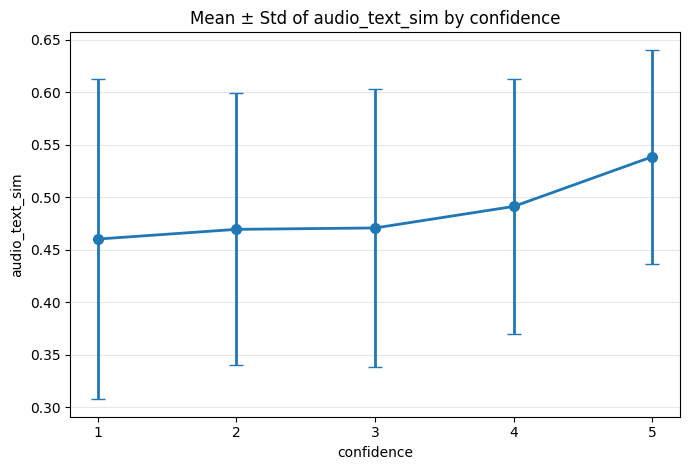

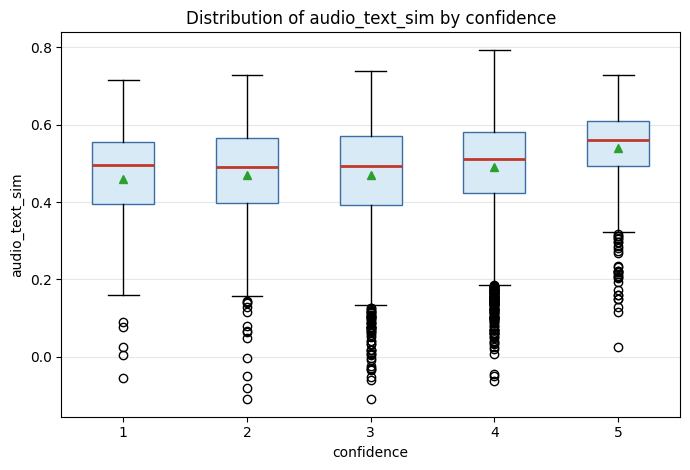

In [18]:
confidence_stats = df.groupby('confidence').agg(
    n=('audio_text_sim', 'size'),
    mean=('audio_text_sim', 'mean'),
    std=('audio_text_sim', 'std'),
    median=('audio_text_sim', 'median'),
    q1=('audio_text_sim', lambda s: s.quantile(0.25)),
    q3=('audio_text_sim', lambda s: s.quantile(0.75)),
).reset_index()

confidence_stats.to_csv(OUT_DIR / 'confidence_mean_std.csv', index=False, encoding='utf-8-sig')
display(confidence_stats.round(4))

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.errorbar(
    confidence_stats['confidence'],
    confidence_stats['mean'],
    yerr=confidence_stats['std'],
    fmt='o-',
    capsize=5,
    linewidth=2,
    markersize=7,
)
ax.set_title('Mean ± Std of audio_text_sim by confidence')
ax.set_xlabel('confidence')
ax.set_ylabel('audio_text_sim')
ax.set_xticks(LABELS)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confidence_mean_std_audio_text_sim.png', dpi=200)
plt.show()

plot_data = [df.loc[df['confidence'] == c, 'audio_text_sim'].values for c in LABELS]
fig, ax = plt.subplots(figsize=(7, 4.8))
box = ax.boxplot(plot_data, labels=LABELS, showmeans=True, patch_artist=True)
for patch in box['boxes']:
    patch.set_facecolor('#D9EAF7')
    patch.set_edgecolor('#3A6EA5')
for median in box['medians']:
    median.set_color('#C0392B')
    median.set_linewidth(2)
ax.set_title('Distribution of audio_text_sim by confidence')
ax.set_xlabel('confidence')
ax.set_ylabel('audio_text_sim')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confidence_boxplot_audio_text_sim.png', dpi=200)
plt.show()

## 4. Cosine similarity 5구간 분류

`audio_text_sim`을 낮은 값부터 높은 값까지 5개 분위수 구간으로 나눈다.

그 다음 각 구간을 예측 confidence 1-5로 매핑한다.

```text
Q1_lowest  -> predicted_confidence = 1
Q2         -> predicted_confidence = 2
Q3         -> predicted_confidence = 3
Q4         -> predicted_confidence = 4
Q5_highest -> predicted_confidence = 5
```

이 방식은 similarity 하나만으로 만든 단순 rule-based classifier다.

In [19]:
bin_labels = ['Q1_pred_1', 'Q2_pred_2', 'Q3_pred_3', 'Q4_pred_4', 'Q5_pred_5']
df['sim_bin'] = pd.qcut(
    df['audio_text_sim'],
    q=5,
    labels=bin_labels,
    duplicates='drop',
)

bin_to_pred = {label: idx + 1 for idx, label in enumerate(bin_labels)}
df['pred_confidence_from_sim'] = df['sim_bin'].map(bin_to_pred).astype(int)

bin_ranges = df.groupby('sim_bin', observed=True).agg(
    predicted_confidence=('pred_confidence_from_sim', 'first'),
    n=('sound_id', 'count'),
    sim_min=('audio_text_sim', 'min'),
    sim_mean=('audio_text_sim', 'mean'),
    sim_max=('audio_text_sim', 'max'),
).reset_index()

df.to_csv(OUT_DIR / 'audio_text_similarity_with_bin_predictions.csv', index=False, encoding='utf-8-sig')
bin_ranges.to_csv(OUT_DIR / 'similarity_bin_ranges.csv', index=False, encoding='utf-8-sig')

display(bin_ranges.round(4))
display(df[['sound_id', 'confidence', 'audio_text_sim', 'sim_bin', 'pred_confidence_from_sim']].head())

,sim_bin,predicted_confidence,n,sim_min,sim_mean,sim_max
0,Q1_pred_1,1,2192,-0.1095,0.2894,0.3893
1,Q2_pred_2,2,2191,0.3894,0.4370,0.4776
2,Q3_pred_3,3,2191,0.4776,0.5089,0.5383
3,Q4_pred_4,4,2191,0.5384,0.5656,0.5934
4,Q5_pred_5,5,2191,0.5934,0.6324,0.7933


,sound_id,confidence,audio_text_sim,sim_bin,pred_confidence_from_sim
0,15,4,0.278695,Q1_pred_1,1
1,21,4,0.276373,Q1_pred_1,1
2,26,3,0.351979,Q1_pred_1,1
3,34,4,0.275505,Q1_pred_1,1
4,39,3,0.395813,Q2_pred_2,2


## 5. 구간별 실제 confidence 개수

아래 표는 similarity 기반으로 `1,2,3,4,5`라고 예측한 각 구간에 실제 confidence 데이터가 몇 개씩 들어갔는지를 보여준다.

행: similarity 기반 predicted confidence

열: 실제 confidence

In [20]:
count_table = pd.crosstab(
    df['pred_confidence_from_sim'],
    df['confidence'],
    rownames=['predicted_by_similarity'],
    colnames=['true_confidence'],
).reindex(index=LABELS, columns=LABELS, fill_value=0)

ratio_table = pd.crosstab(
    df['pred_confidence_from_sim'],
    df['confidence'],
    normalize='index',
    rownames=['predicted_by_similarity'],
    colnames=['true_confidence'],
).reindex(index=LABELS, columns=LABELS, fill_value=0)

count_table.to_csv(OUT_DIR / 'similarity_bin_true_confidence_counts.csv', encoding='utf-8-sig')
ratio_table.to_csv(OUT_DIR / 'similarity_bin_true_confidence_ratios.csv', encoding='utf-8-sig')

print('Counts: predicted confidence by similarity bin vs true confidence')
display(count_table)
print('Ratios within each predicted bin')
display(ratio_table.round(4))

Counts: predicted confidence by similarity bin vs true confidence


true_confidence,1,2,3,4,5
predicted_by_similarity,,,,,
1,26,173,805,1123,65
2,20,176,686,1208,101
3,25,158,614,1240,154
4,17,116,612,1243,203
5,18,126,563,1231,253


Ratios within each predicted bin


true_confidence,1,2,3,4,5
predicted_by_similarity,,,,,
1,0.0119,0.0789,0.3672,0.5123,0.0297
2,0.0091,0.0803,0.3131,0.5513,0.0461
3,0.0114,0.0721,0.2802,0.5660,0.0703
4,0.0078,0.0529,0.2793,0.5673,0.0927
5,0.0082,0.0575,0.2570,0.5618,0.1155


## 6. Accuracy / Precision / Recall / F1

similarity 5구간을 confidence 1-5 예측값으로 간주하고 실제 confidence와 비교한다.

- Accuracy: 전체 중 예측 confidence가 실제 confidence와 정확히 같은 비율
- Precision: 특정 confidence로 예측한 것 중 실제로 그 confidence인 비율
- Recall: 실제 특정 confidence 중 그 confidence로 맞게 예측한 비율
- F1: precision과 recall의 조화 평균

confidence 분포가 불균형하므로 macro 평균과 weighted 평균을 같이 본다.

In [21]:
y_true = df['confidence'].astype(int)
y_pred = df['pred_confidence_from_sim'].astype(int)

accuracy = accuracy_score(y_true, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=LABELS, average='macro', zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=LABELS, average='weighted', zero_division=0
)

metric_summary = pd.DataFrame([
    {
        'method': 'audio_text_sim_quantile_5bin',
        'accuracy': accuracy,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }
])

metric_summary.to_csv(OUT_DIR / 'similarity_5bin_metrics.csv', index=False, encoding='utf-8-sig')
display(metric_summary.round(4))

,method,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,audio_text_sim_quantile_5bin,0.211,0.211,0.2398,0.1678,0.4107,0.211,0.2542


## 7. Confusion Matrix와 Classification Report

In [22]:
cm = pd.DataFrame(
    confusion_matrix(y_true, y_pred, labels=LABELS),
    index=[f'true_{x}' for x in LABELS],
    columns=[f'pred_{x}' for x in LABELS],
)
cm.to_csv(OUT_DIR / 'similarity_5bin_confusion_matrix.csv', encoding='utf-8-sig')
display(cm)

report_text = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    output_dict=True,
    zero_division=0,
)

(OUT_DIR / 'similarity_5bin_classification_report.txt').write_text(report_text, encoding='utf-8')
pd.DataFrame(report_dict).T.to_csv(OUT_DIR / 'similarity_5bin_classification_report.csv', encoding='utf-8-sig')

print(report_text)

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,26,20,25,17,18
true_2,173,176,158,116,126
true_3,805,686,614,612,563
true_4,1123,1208,1240,1243,1231
true_5,65,101,154,203,253


              precision    recall  f1-score   support

confidence_1       0.01      0.25      0.02       106
confidence_2       0.08      0.23      0.12       749
confidence_3       0.28      0.19      0.22      3280
confidence_4       0.57      0.21      0.30      6045
confidence_5       0.12      0.33      0.17       776

    accuracy                           0.21     10956
   macro avg       0.21      0.24      0.17     10956
weighted avg       0.41      0.21      0.25     10956



## 8. 리포트 저장

In [23]:
means = confidence_stats.set_index('confidence')['mean']
is_mean_monotonic_increasing = bool((means.diff().dropna() >= 0).all())

summary = {
    'n_rows': int(len(df)),
    'is_mean_monotonic_increasing': is_mean_monotonic_increasing,
    'confidence_5_mean_minus_confidence_1_mean': float(means.loc[5] - means.loc[1]),
    'confidence_5_mean_minus_confidence_4_mean': float(means.loc[5] - means.loc[4]),
    'similarity_5bin_accuracy': float(accuracy),
    'similarity_5bin_macro_precision': float(macro_p),
    'similarity_5bin_macro_recall': float(macro_r),
    'similarity_5bin_macro_f1': float(macro_f1),
    'output_dir': str(OUT_DIR),
}

report_lines = []
report_lines.append('# audio_text_sim confidence 평가 결과')
report_lines.append('')
report_lines.append('## Confidence별 Mean ± Std')
report_lines.append(confidence_stats.round(4).to_markdown(index=False))
report_lines.append('')
report_lines.append('## Similarity 5-bin ranges')
report_lines.append(bin_ranges.round(4).to_markdown(index=False))
report_lines.append('')
report_lines.append('## Similarity 5-bin true confidence counts')
report_lines.append(count_table.to_markdown())
report_lines.append('')
report_lines.append('## Similarity 5-bin metrics')
report_lines.append(metric_summary.round(4).to_markdown(index=False))
report_lines.append('')
report_lines.append('## Classification report')
report_lines.append('```text')
report_lines.append(report_text)
report_lines.append('```')
report_lines.append('')
report_lines.append('## 저장된 그림')
report_lines.append('- plots/confidence_mean_std_audio_text_sim.png')
report_lines.append('- plots/confidence_boxplot_audio_text_sim.png')

(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
(OUT_DIR / 'audio_text_sim_confidence_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

print('saved:', OUT_DIR / 'audio_text_sim_confidence_report.md')
print('saved:', OUT_DIR / 'summary.json')

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

## 9. 종합 판단 지표 계산

`audio_text_sim`이 confidence와 얼마나 관련 있는지를 정량적으로 요약한다.

- **Spearman 상관계수**: 순위 기반 상관 (단조성 측정)
- **Q5 vs Q1 mean confidence 차이**: 높은 similarity 구간이 실제로 high confidence 샘플을 더 많이 담는가
- **Q5 high_conf_rate_4_5 lift**: Q5의 고신뢰도 비율이 전체 대비 얼마나 높은가

In [ ]:
from scipy.stats import spearmanr

# Spearman correlation between audio_text_sim and confidence
spearman_corr, spearman_pval = spearmanr(df['audio_text_sim'], df['confidence'])

# Q1, Q5 빈별 mean confidence 및 고신뢰도(4~5) 비율
bin_stats = df.groupby('sim_bin', observed=True).agg(
    mean_confidence=('confidence', 'mean'),
    high_conf_rate_4_5=('confidence', lambda s: (s >= 4).mean()),
).reset_index()
bin_stats['sim_bin_str'] = bin_stats['sim_bin'].astype(str)

q1_row = bin_stats[bin_stats['sim_bin_str'] == 'Q1_pred_1'].iloc[0]
q5_row = bin_stats[bin_stats['sim_bin_str'] == 'Q5_pred_5'].iloc[0]

overall_high_conf_rate = (df['confidence'] >= 4).mean()
top_bin_lift = (
    float(q5_row['high_conf_rate_4_5']) / overall_high_conf_rate
    if overall_high_conf_rate > 0 else 0.0
)

summary_metrics = pd.DataFrame([{
    'delta_q5_minus_q1_mean_confidence':    float(q5_row['mean_confidence'] - q1_row['mean_confidence']),
    'delta_q5_minus_q1_high_conf_rate_4_5': float(q5_row['high_conf_rate_4_5'] - q1_row['high_conf_rate_4_5']),
    'top_bin_high_conf_lift_vs_overall':     float(top_bin_lift),
    'spearman_corr':                         float(spearman_corr),
    'spearman_pval':                         float(spearman_pval),
}])

summary_metrics.to_csv(OUT_DIR / 'summary_metrics.csv', index=False, encoding='utf-8-sig')
display(summary_metrics.round(4))